In [ ]:
import os
import re
import time
from urllib.parse import urljoin
import json
import pandas as pd

import spotipy
from spotipy.oauth2 import SpotifyClientCredentials


from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [ ]:
CLIENT_ID = '6037db494e7e459f9743e36800fe7c7c'
CLIENT_SECRET = '9f2deeadc47f4487a8b1374c28ff354b'

sp = spotipy.Spotify(
    auth_manager=SpotifyClientCredentials(
        client_id=CLIENT_ID, 
        client_secret=CLIENT_SECRET
        )
    )

# Test Spotify API Connection
try:
    results = sp.search(q='hello world', type='track', limit=1)
    if results['tracks']['items']:
        formatted_json = json.dumps(results, indent=2, ensure_ascii=False)
        print(formatted_json)
        print("================================================")
        print("Successfully connected to Spotify API!")
        print(results['tracks']['items'][0]['artists'][0]['id']) # artist id
        artist_id = results['tracks']['items'][0]['artists'][0]['id']
        print(f"Find: {results['tracks']['items'][0]['artists'][0]['name']}'s '{results['tracks']['items'][0]['name']}' ")
    else:
        print("Successfully connected to Spotify API! Nothing founded.")
except Exception as e:
    print(f"Failed to connected: {e}...")

## Fetch all country names

In [ ]:
def fetch_spotify_countries():
    options = Options()
    options.add_argument("--start-maximized")

    driver = webdriver.Chrome(options=options)
    driver.get("https://charts.spotify.com/charts/overview/global")

    input("Afterlogin please press Enter...")
    time.sleep(3)

    items = driver.find_elements(By.CSS_SELECTOR, 'li[role="option"][data-key]')
    print(f"Found {len(items)} country/region options")

    html_list = [li.get_attribute("outerHTML") for li in items]
    driver.quit()

    country_list = []
    for html in html_list:
        soup = BeautifulSoup(html, "html.parser")
        li = soup.find("li")
        if not li:
            continue

        data_key = li.get("data-key", "")
        name = li.get_text(strip=True)

        if data_key.startswith("/charts/overview/") and name:
            code = data_key.split("/")[-1]
            country_list.append({
                "code": code,
                "name": name,
                "data_key": data_key
            })

    return pd.DataFrame(country_list).drop_duplicates()

country_df = fetch_spotify_countries()
print(country_df.head(20))
print(country_df.shape)
country_df.to_csv("spotify_countries.csv", index=False)

## Fetch all countries top weekely songs
1. use the country dictionary previous we got
2. web script weekely data and save into csv

In [ ]:

# =========================================================
# Basic settings
# =========================================================
SPOTIFY_EMAIL = "0524andrea2405@gmail.com"

COUNTRY_CSV_PATH = "spotify_countries.csv"   
OUTPUT_DIR = "spotify_weekly_top_songs"      
PROGRESS_FILE = "progress.json"                                

BASE_URL = "https://charts.spotify.com/home"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# Build driver
# =========================================================
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 20)

# =========================================================
# 1) Import COUNTRY_MAP from csv file
#    key = code, value = name
# =========================================================
def load_country_map(csv_path):
    df = pd.read_csv(csv_path)
    required_cols = {"code", "name"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"CSV must contain columns: {required_cols}")

    country_map = dict(zip(df["code"].astype(str).str.strip(), df["name"].astype(str).str.strip()))
    return country_map, df

COUNTRY_MAP, country_df = load_country_map(COUNTRY_CSV_PATH)
weekly_top_music_by_country = {code: None for code in COUNTRY_MAP.keys()}

# =========================================================
# Utilities
# =========================================================
def sanitize_filename(text):
    text = str(text).strip()
    text = re.sub(r"[\\/:\*\?\"<>\|]", "_", text)
    text = re.sub(r"\s+", "_", text)
    return text

def get_output_csv_path(country_code, country_name):
    safe_name = sanitize_filename(country_name)
    return os.path.join(OUTPUT_DIR, f"{country_code}_{safe_name}_weekly_top_songs.csv")

def load_progress(progress_file):
    if os.path.exists(progress_file):
        with open(progress_file, "r", encoding="utf-8") as f:
            return json.load(f)
    return {
        "completed": [],
        "failed": [],
        "last_country": None
    }

def save_progress(progress_file, progress_data):
    with open(progress_file, "w", encoding="utf-8") as f:
        json.dump(progress_data, f, ensure_ascii=False, indent=2)

progress = load_progress(PROGRESS_FILE)


# =========================================================
# 2) Open home page
# =========================================================
def open_spotify_charts_home(driver):
    driver.get(BASE_URL)
    time.sleep(2)


# =========================================================
# 3) Login flow 
# =========================================================
def spotify_login(driver, wait, email):
    print("Entering login flow...")

    login_btn = wait.until(
        EC.presence_of_element_located((
            By.XPATH,
            "//span[normalize-space()='Log in']/ancestor::button[1] | "
            "//span[normalize-space()='Log in']/ancestor::a[1] | "
            "//button[contains(., 'Log in')] | //a[contains(., 'Log in')]"
        ))
    )

    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", login_btn)
    time.sleep(1)
    driver.execute_script("arguments[0].click();", login_btn)

    email_input = wait.until(
        EC.presence_of_element_located((By.CSS_SELECTOR, 'input[data-testid="login-username"]'))
    )
    email_input.clear()
    email_input.send_keys(email)

    continue_btn = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, 'button[data-testid="login-button"]'))
    )
    continue_btn.click()

    print("Please complete the login / verification in the browser.")
    input("After completion, return to the notebook / terminal and press Enter to continue...")
    print("Login completed.")


# =========================================================
# 4) Click Weekly Top Songs
# =========================================================
def click_weekly_top_songs(driver, wait):
    possible_xpaths = [
        "//a[contains(., 'Weekly Top Songs')]",
        "//button[contains(., 'Weekly Top Songs')]",
        "//span[contains(., 'Weekly Top Songs')]/ancestor::*[self::a or self::button][1]",
        "//*[contains(text(), 'Weekly Top Songs')]"
    ]

    for xp in possible_xpaths:
        try:
            elem = wait.until(EC.element_to_be_clickable((By.XPATH, xp)))
            driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", elem)
            time.sleep(1)
            driver.execute_script("arguments[0].click();", elem)
            time.sleep(3)
            print("Weekly Top Songs clicked")
            return
        except Exception:
            continue

    raise Exception("Weekly Top Songs button not found")

# =========================================================
# 5) Choose country
# =========================================================
def clear_input_mac_or_windows(search_input):
    try:
        # Mac
        search_input.send_keys(Keys.COMMAND, "a")
        time.sleep(0.3)
        search_input.send_keys(Keys.DELETE)
    except Exception:
        # Windows fallback
        search_input.send_keys(Keys.CONTROL, "a")
        time.sleep(0.3)
        search_input.send_keys(Keys.DELETE)

def select_country(driver, wait, country_code, country_name):
    print(f"Choosing country: {country_code} - {country_name}")

    # Search box
    search_input = wait.until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, 'input[data-testid="search-input"]'))
    )

    search_input.click()
    time.sleep(0.5)
    clear_input_mac_or_windows(search_input)
    time.sleep(0.5)

    search_input.send_keys(country_name)
    time.sleep(2)

    option_locator = (
        By.XPATH,
        f"//div[@role='option' and contains(., '{country_name}')] | "
        f"//li[@role='option' and contains(., '{country_name}')] | "
        f"//*[contains(@role, 'option') and contains(., '{country_name}')]"
    )

    committed = False

    # Method 1: Try keyboard selection first
    try:
        wait.until(EC.presence_of_element_located(option_locator))
        time.sleep(0.5)
        search_input.send_keys(Keys.ARROW_DOWN)
        time.sleep(0.3)
        search_input.send_keys(Keys.ENTER)
        committed = True
    except Exception:
        pass

    # Method 2: Directly click option
    if not committed:
        option_xpaths = [
            f"//div[@role='option' and contains(., '{country_name}')]",
            f"//li[@role='option' and contains(., '{country_name}')]",
            f"//*[contains(@role, 'option') and contains(., '{country_name}')]",
        ]

        for xp in option_xpaths:
            try:
                option = wait.until(EC.element_to_be_clickable((By.XPATH, xp)))
                driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", option)
                time.sleep(0.5)
                driver.execute_script("arguments[0].click();", option)
                committed = True
                break
            except Exception:
                continue

    # Method 3: Directly press Enter
    if not committed:
        search_input.send_keys(Keys.ENTER)
        committed = True

    time.sleep(2)

    final_value = driver.find_element(
        By.CSS_SELECTOR,
        'input[data-testid="search-input"]'
    ).get_attribute("value")

    print(f"Country selected: {country_name} | input value = {final_value}")


# =========================================================
# 6) Scroll to bottom, to ensure table is fully rendered
# =========================================================
def scroll_to_bottom(driver, pause_time=2, max_rounds=10):
    last_height = driver.execute_script("return document.body.scrollHeight")

    for _ in range(max_rounds):
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(pause_time)
        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break
        last_height = new_height


# =========================================================
# 7) Scrape raw table data
#    Expected to capture 6 columns:
#    rank, track_artist, peak, prev, streak, streams
# =========================================================
def scrape_chart_table_raw(driver):
    rows_data = []

    scroll_to_bottom(driver, pause_time=2, max_rounds=8)
    time.sleep(2)

    possible_row_xpaths = [
        "//table//tr",
        "//div[@role='row']"
    ]

    rows = []
    for xp in possible_row_xpaths:
        found = driver.find_elements(By.XPATH, xp)
        if found:
            rows = found
            break

    for row in rows:
        try:
            cells = row.find_elements(By.XPATH, ".//td | .//div[@role='cell']")
            texts = [c.text.strip() for c in cells if c.text.strip()]

            if len(texts) >= 6:
                rows_data.append(texts[:6])

        except Exception:
            continue

    return rows_data


# =========================================================
# 8) Single Country Process
# =========================================================
# ORIGINAL VERSION
# def process_one_country(driver, wait, country_code, country_name):
#     select_country(driver, wait, country_code, country_name)
#     time.sleep(2)

#     raw_rows = scrape_chart_table_raw(driver)
#     print(f"{country_code} Raw data scraped: {len(raw_rows)} rows")
#     df_country = pd.DataFrame(raw_rows)  
#     
#     return df_country

def process_one_country(driver, wait, country_code, country_name):
    select_country(driver, wait, country_code, country_name)
    time.sleep(2)

    raw_rows = scrape_chart_table_raw(driver)
    print(f"{country_code} Raw data scraped: {len(raw_rows)} rows")

    expected_cols = ['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams']
    df_country = pd.DataFrame(raw_rows, columns=expected_cols)

    df_country = df_country.apply(lambda col: col.astype(str).str.strip())

    df_country['rank'] = df_country['rank'].str.extract(r'(\d+)', expand=False)

    df_country[['track_name', 'artist_name']] = (
        df_country['track_artist']
        .astype(str)
        .str.split('\n', n=1, expand=True)
    )

    df_country['track_name'] = df_country['track_name'].str.strip()
    df_country['artist_name'] = df_country['artist_name'].str.strip()

    df_country['streams'] = (
        df_country['streams']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.extract(r'(\d+)', expand=False)
    )

    for col in ['rank', 'peak', 'prev', 'streak', 'streams']:
        df_country[col] = pd.to_numeric(df_country[col], errors='coerce')

    return df_country


# =========================================================
# 9) Main flow with progress tracking and error handling
# =========================================================
all_country_frames = []

try:
    open_spotify_charts_home(driver)
    spotify_login(driver, wait, SPOTIFY_EMAIL)
    click_weekly_top_songs(driver, wait)

    completed_set = set(progress.get("completed", []))
    failed_set = set(progress.get("failed", []))

    for country_code, country_name in COUNTRY_MAP.items():

        if country_code in completed_set:
            print(f"[SKIP] {country_code} - {country_name} had already finished, skipping...")
            csv_path = get_output_csv_path(country_code, country_name)
            if os.path.exists(csv_path):
                weekly_top_music_by_country[country_code] = pd.read_csv(csv_path)
            continue

        try:
            print("=" * 80)
            print(f"Starting: {country_code} - {country_name}")

            df_country = process_one_country(driver, wait, country_code, country_name)
            weekly_top_music_by_country[country_code] = df_country

            # save individual country csv
            csv_path = get_output_csv_path(country_code, country_name)
            df_country.to_csv(csv_path, index=False, encoding="utf-8-sig")
            print(f"Saved: {csv_path}")

            # all_country_frames
            df_tmp = df_country.copy()
            df_tmp["country_code"] = country_code
            df_tmp["country_name"] = country_name
            all_country_frames.append(df_tmp)

            # Update progress
            completed_set.add(country_code)
            if country_code in failed_set:
                failed_set.remove(country_code)

            progress["completed"] = sorted(list(completed_set))
            progress["failed"] = sorted(list(failed_set))
            progress["last_country"] = country_code
            save_progress(PROGRESS_FILE, progress)

            print(f"[DONE] {country_code} - {country_name}")

        except Exception as e:
            print(f"[ERROR] {country_code} - {country_name}: {e}")

            failed_set.add(country_code)
            progress["completed"] = sorted(list(completed_set))
            progress["failed"] = sorted(list(failed_set))
            progress["last_country"] = country_code
            save_progress(PROGRESS_FILE, progress)

            continue


except KeyboardInterrupt:
    print("Program manually stopped, progress.json and individual country csv files are preserved.")

finally:
    print("Process completed.")

In [ ]:
def rename_columns_and_clean_data(df):
    df = df.rename(columns={
        '0': 'rank',
        '1': 'track_artist',
        '2': 'peak',
        '3': 'prev',
        '4': 'streak',
        '5': 'streams'
    })

    df[['track_name', 'artist_name']] = (
        df['track_artist']
        .astype(str)
        .str.split('\n', n=1, expand=True)
    )

    df['track_name'] = df['track_name'].str.strip()
    df['artist_name'] = df['artist_name'].str.strip()

    df['streams'] = (
        df['streams']
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    for col in ['rank', 'peak', 'prev', 'streak', 'streams']:
        df[col] = pd.to_numeric(
            df[col],
            errors='coerce'
        )
    return df

for country_code, country_name in COUNTRY_MAP.items():
    if country_code in progress.get("completed", []):
        print(f"[CLEAN] {country_code} - {country_name}")
        csv_path = get_output_csv_path(country_code, country_name)
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            cleaned_df = rename_columns_and_clean_data(df)
            cleaned_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
            weekly_top_music_by_country[country_code] = cleaned_df
            print(f"Cleaned and saved: {csv_path}")

# Main Funcitons

## 0. Read every information from csv

In [ ]:
from pathlib import Path

base_dir = Path.cwd()  
csv_dir = base_dir / "spotify_weekly_top_songs"

weekly_top_music_by_country = {}

for csv_file in csv_dir.glob("*.csv"):
    filename = csv_file.stem
    key = filename.split("_")[0]
    df = pd.read_csv(csv_file)
    df["rank"] = df.index + 1
    weekly_top_music_by_country[key] = df

for k, v in weekly_top_music_by_country.items():
    print(f"{k}:")
    print(v.head())
    print("-" * 40)

In [ ]:
df_now = weekly_top_music_by_country['global']
df_now['rank'] = df_now.index + 1
df_now
print(df_now.columns)

## 1. Get needed informations

Already have ['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams', 'track_name', 'artist_name']

Need duration_ms, explicit, is_local, release_date, artist_id, track_id

### 1.1 try one df

In [ ]:
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# =========================
# 0. Spotify client
# =========================
auth_manager = SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)

sp = spotipy.Spotify(
    auth_manager=auth_manager,
    requests_timeout=10,
    retries=3
)

# =========================
# 1. function: query one row
# =========================
def get_track_metadata(row, sp):
    track_name = str(row["track_name"]).strip()
    artist_name = str(row["artist_name"]).strip()

    default_result = pd.Series({
        "duration_ms": pd.NA,
        "explicit": pd.NA,
        "is_local": pd.NA,
        "release_date": pd.NA,
        "artist_id": pd.NA,
        "track_id": pd.NA
    })

    if not track_name or track_name.lower() == "nan":
        return default_result

    try:
        q = f'track:"{track_name}" artist:"{artist_name}"'
        result = sp.search(q=q, type="track", limit=1)

        items = result.get("tracks", {}).get("items", [])
        if not items:
            return default_result

        track = items[0]

        return pd.Series({
            "duration_ms": track.get("duration_ms"),
            "explicit": track.get("explicit"),
            "is_local": track.get("is_local"),
            "release_date": track.get("album", {}).get("release_date"),
            "artist_id": track.get("artists", [{}])[0].get("id"),
            "track_id": track.get("id")
        })

    except Exception as e:
        print(f"Error on track='{track_name}', artist='{artist_name}': {e}")
        return default_result

# =========================
# 2. apply back to df
# =========================
df_now[[
    "duration_ms",
    "explicit",
    "is_local",
    "release_date",
    "artist_id",
    "track_id"
]] = df_now.apply(get_track_metadata, axis=1, sp=sp)
df_now["duration_ms"] = pd.to_numeric(df_now["duration_ms"], errors="coerce")
df_now["duration_sec"] = (df_now["duration_ms"] / 1000).round().astype("Int64")

print(df_now.head())

### 1.2 try every df

In [ ]:
import os
import re
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

# =========================
# 0. Spotify client
# =========================
auth_manager = SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
)

sp = spotipy.Spotify(
    auth_manager=auth_manager,
    requests_timeout=10,
    retries=3
)

# =========================
# 1. query one row
# =========================
def get_track_metadata(row, sp):
    track_name = str(row["track_name"]).strip()
    artist_name = str(row["artist_name"]).strip()

    default_result = pd.Series({
        "duration_ms": pd.NA,
        "explicit": pd.NA,
        "is_local": pd.NA,
        "release_date": pd.NA,
        "artist_id": pd.NA,
        "track_id": pd.NA
    })

    if not track_name or track_name.lower() == "nan":
        return default_result

    try:
        q = f'track:"{track_name}" artist:"{artist_name}"'
        result = sp.search(q=q, type="track", limit=1)

        time.sleep(0.2)

        items = result.get("tracks", {}).get("items", [])
        if not items:
            return default_result

        track = items[0]

        return pd.Series({
            "duration_ms": track.get("duration_ms"),
            "explicit": track.get("explicit"),
            "is_local": track.get("is_local"),
            "release_date": track.get("album", {}).get("release_date"),
            "artist_id": track.get("artists", [{}])[0].get("id"),
            "track_id": track.get("id")
        })

    except Exception as e:
        print(f"Error on track='{track_name}', artist='{artist_name}': {e}")
        return default_result


# =========================
# 2. clean filename
# =========================
def clean_filename(name):
    name = str(name).strip()
    name = re.sub(r'[\\/*?:"<>|]', "_", name)   
    name = re.sub(r"\s+", "_", name)            
    return name


# =========================
# 3. process one dataframe
# =========================
def enrich_one_df(df, sp):
    df = df.copy()

    # 補 metadata
    df[[
        "duration_ms",
        "explicit",
        "is_local",
        "release_date",
        "artist_id",
        "track_id"
    ]] = df.apply(get_track_metadata, axis=1, sp=sp)

    df["duration_ms"] = pd.to_numeric(df["duration_ms"], errors="coerce")
    df["duration_sec"] = (df["duration_ms"] / 1000).round().astype("Int64")

    text_cols = ["release_date", "artist_id", "track_id"]
    df[text_cols] = df[text_cols].fillna("unknown")

    bool_cols = ["explicit", "is_local"]
    df[bool_cols] = df[bool_cols].astype("object").fillna("unknown")

    return df


# =========================
# 4. process dictionary and save csv
# =========================
def enrich_dict_and_save_csv(df_dict, sp, output_folder="spotify_weekly_top_song_all_info"):
    os.makedirs(output_folder, exist_ok=True)

    enriched_dict = {}

    for key, df in df_dict.items():
        print(f"Processing: {key}")

        try:
            enriched_df = enrich_one_df(df, sp)

            enriched_dict[key] = enriched_df

            safe_name = clean_filename(key)
            output_path = os.path.join(output_folder, f"{safe_name}.csv")
            enriched_df.to_csv(output_path, index=False, encoding="utf-8-sig")

            print(f"Saved: {output_path}")

        except Exception as e:
            print(f"Failed on {key}: {e}")

    return enriched_dict


all_country_dfs_enriched = enrich_dict_and_save_csv(
    df_dict=weekly_top_music_by_country,
    sp=sp,
    output_folder="spotify_weekly_top_song_all_info"
)
all_country_dfs_enriched["taiwan"].head()

## 2. Get connect to GENIUS

1. Get song original url

2. Search if have english translate url

3. Scrap lyric

In [ ]:
GENIUS_ACCESS_TOKEN = "RRq13wjZwuS58WGJGEphihGV8yAlIyke3fJoUh0mTVdCmo3tzI4j-vkyTQfLgHuE"

import requests
import pandas as pd
import time
import random
from bs4 import BeautifulSoup


session = requests.Session()
session.headers.update({
    "Authorization": f"Bearer {GENIUS_ACCESS_TOKEN}",
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/145.0.0.0 Safari/537.36"
})

# =========================
# 1. Search Genius API for song URL
# =========================
def search_genius_song_url(track_name, artist_name=None, timeout=15):
    query = str(track_name).strip()
    if artist_name and pd.notna(artist_name):
        query += f" {str(artist_name).strip()}"

    url = "https://api.genius.com/search"
    params = {"q": query}

    try:
        resp = session.get(url, params=params, timeout=timeout)
        resp.raise_for_status()
        data = resp.json()
    except Exception as e:
        print(f"[search error] {track_name} / {artist_name}: {e}")
        return None

    hits = data.get("response", {}).get("hits", [])
    if not hits:
        return None

    for hit in hits:
        if hit.get("type") == "song":
            result = hit.get("result", {})
            return result.get("url")

    return hits[0].get("result", {}).get("url")

# result = search_genius_song_url("DtMF")
# print(result)

In [ ]:
from bs4 import BeautifulSoup
import re

# =========================
# 2. Scrape lyrics from Genius page
# =========================
def scrape_genius_lyrics(song_url, timeout=15):
    if not song_url:
        return None

    try:
        resp = session.get(song_url, timeout=timeout)
        resp.raise_for_status()
    except Exception as e:
        print(f"[lyrics page error] {song_url}: {e}")
        return None

    soup = BeautifulSoup(resp.text, "lxml")
    containers = soup.select('div[data-lyrics-container="true"]')

    if not containers:
        return None

    lyrics_blocks = []

    for c in containers:
        for bad in c.select('[data-exclude-from-selection="true"]'):
            bad.decompose()

        for br in c.find_all("br"):
            br.replace_with("\n")

        for tag in c.find_all(["a", "span", "i"]):
            tag.unwrap()

        text = c.get_text(separator="", strip=False)

        text = re.sub(r"\r", "", text)
        text = re.sub(r"[ \t]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        text = text.strip()

        if text:
            lyrics_blocks.append(text)

    lyrics = "\n".join(lyrics_blocks).strip()

    return lyrics if lyrics else None

# result_lyrics = scrape_genius_lyrics(result)
# print(result_lyrics)

In [ ]:
# =========================
# 3. Get lyrics for one row with polite delay
# =========================
def get_lyrics_for_row(track_name, artist_name=None, sleep_low=0.8, sleep_high=1.5):
    song_url = search_genius_song_url(track_name, artist_name)
    time.sleep(random.uniform(sleep_low, sleep_high))  # polite delay after API search

    lyrics = scrape_genius_lyrics(song_url)
    time.sleep(random.uniform(sleep_low, sleep_high))  # polite delay after page fetch

    return song_url, lyrics

### 2.1 Get all songs lyric using global_df

In [ ]:
import pandas as pd
import time
import random

df_lyric = df_now.copy()

df_lyric["genius_url"] = pd.NA
df_lyric["lyrics"] = pd.NA

for idx, row in df_lyric.iterrows():
    track_name = row.get("track_name")
    artist_name = row.get("artist_name")

    print(f"Processing idx={idx}: {track_name} - {artist_name}")

    try:
        song_url, lyrics = get_lyrics_for_row(track_name, artist_name)

        df_lyric.at[idx, "genius_url"] = song_url if song_url else pd.NA
        df_lyric.at[idx, "lyrics"] = lyrics if lyrics else pd.NA

    except Exception as e:
        print(f"[row error] idx={idx}: {e}")
        df_lyric.at[idx, "genius_url"] = None
        df_lyric.at[idx, "lyrics"] = None
        continue

df_lyric.to_csv("global_top_lyrics_original.csv", index=False, encoding="utf-8-sig")

Make sure all lyrics are in English Version

In [ ]:
def find_english_translation_url(song_url, timeout=15):
    try:
        resp = session.get(song_url, timeout=timeout)
        resp.raise_for_status()
    except Exception as e:
        print(f"[page error] {song_url}: {e}")
        return None

    soup = BeautifulSoup(resp.text, "html.parser")

    for a in soup.find_all("a", href=True):
        href = a["href"]
        text = a.get_text(" ", strip=True).lower()

        if "english translation" in text:
            return href

        if "english-translation-lyrics" in href.lower():
            return href

    return None

df_lyric["genius_url_org"] = df_lyric["genius_url"]
df_lyric["english_translation_url"] = df_lyric["genius_url_org"].apply(find_english_translation_url)
df_lyric["has_english_translation"] = df_lyric["english_translation_url"].notna()
df_lyric["genius_url"] = df_lyric["english_translation_url"].combine_first(df_lyric["genius_url_org"])

for idx in df_lyric.index[df_lyric["english_translation_url"].notna()]:
    print(f"Fetching English translation for idx={idx}: {df_lyric.at[idx, 'track_name']} - {df_lyric.at[idx, 'artist_name']}")
    url = df_lyric.at[idx, "english_translation_url"]
    new_lyrics = scrape_genius_lyrics(url)

    if new_lyrics is not None:
        df_lyric.at[idx, "lyrics"] = new_lyrics

df_lyric.to_csv("global_top_lyrics_english.csv", index=False, encoding="utf-8-sig")

#### read original lyric from csv

In [ ]:
df_lyric = pd.read_csv("global_top_lyrics_english.csv")
print(df_lyric['lyrics'][5])

In [ ]:
import re
import pandas as pd

def clean_lyrics_and_count_sections(text):
    """
    Clean lyric text from Genius:
    1. Keep only from the first section label (e.g., [Verse 1], [Chorus], [Intro])
       and remove all noise before it
    2. Remove all section labels like [Verse 1], [Chorus], [Verse 2]
    3. Return cleaned lyrics + count of each section
    """
    if pd.isna(text) or not str(text).strip():
        return {
            "lyrics_clean": None,
            "verse_1_count": 0,
            "verse_2_count": 0,
            "chorus_count": 0,
            "post_chorus_count": 0,
            "verse_total_count": 0,
            "pre_chorus_count": 0,
            "bridge_count": 0,
            "intro_count": 0,
            "outro_count": 0,
            "hook_count": 0,
            "refrain_count": 0,
            "all_section_labels": []
        }

    text = str(text).replace("\r\n", "\n").replace("\r", "\n").strip()

    # ========= 1. find all section labels =========
    all_labels = re.findall(r"\[(.*?)\]", text)

    # ========= 2. Keep only from the first section label, remove all noise before it =========
    first_section_match = re.search(r"\[[^\]]+\]", text)
    if first_section_match:
        text = text[first_section_match.start():]
    else:
        cleaned = re.sub(r"[ \t]+", " ", text)
        cleaned = re.sub(r"\n{2,}", "\n", cleaned).strip()
        return {
            "lyrics_clean": cleaned if cleaned else None,
            "verse_1_count": 0,
            "verse_2_count": 0,
            "chorus_count": 0,
            "post_chorus_count": 0,
            "verse_total_count": 0,
            "pre_chorus_count": 0,
            "bridge_count": 0,
            "intro_count": 0,
            "outro_count": 0,
            "hook_count": 0,
            "refrain_count": 0,
            "all_section_labels": []
        }

    # ========= 3. Count section occurrences =========
    labels_lower = [label.lower().strip() for label in all_labels]

    def count_pattern(pattern):
        return sum(bool(re.search(pattern, label, flags=re.I)) for label in labels_lower)

    verse_1_count = count_pattern(r"\bverse\s*1\b")
    verse_2_count = count_pattern(r"\bverse\s*2\b")
    chorus_count = count_pattern(r"\bchorus\b")
    post_chorus_count = count_pattern(r"\bpost[- ]?chorus\b")
    verse_total_count = count_pattern(r"\bverse\b")
    pre_chorus_count = count_pattern(r"\bpre[- ]?chorus\b")
    bridge_count = count_pattern(r"\bbridge\b")
    intro_count = count_pattern(r"\bintro\b")
    outro_count = count_pattern(r"\boutro\b")
    hook_count = count_pattern(r"\bhook\b")
    refrain_count = count_pattern(r"\brefrain\b")

    # ========= 4. Remove all [section] labels =========
    text = re.sub(r"\[[^\]]+\]", " ", text)

    # ========= 5. Clean up extra whitespace =========
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    text = text.strip()

    return {
        "lyrics_clean": text if text else None,
        "verse_1_count": verse_1_count,
        "verse_2_count": verse_2_count,
        "chorus_count": chorus_count,
        "post_chorus_count": post_chorus_count,
        "verse_total_count": verse_total_count,
        "pre_chorus_count": pre_chorus_count,
        "bridge_count": bridge_count,
        "intro_count": intro_count,
        "outro_count": outro_count,
        "hook_count": hook_count,
        "refrain_count": refrain_count,
        "all_section_labels": all_labels
    }

section_info = df_lyric["lyrics"].apply(clean_lyrics_and_count_sections).apply(pd.Series)

df_lyric = pd.concat([df_lyric, section_info], axis=1)

In [ ]:
df_lyric.to_csv("global_top_lyrics_cleaned.csv", index=False, encoding="utf-8-sig")
df_lyric['lyrics_clean'].iloc[0]

#### read cleaned lyric from csv

In [ ]:
df_lyric = pd.read_csv("global_top_lyrics_cleaned.csv")
print(df_lyric.columns)

### 2.2 Try to compute word frequency

In [ ]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# =========================
# 1. prepare data
# =========================
df_nlp = df_lyric.copy()

df_nlp = df_nlp[
    df_nlp["lyrics_clean"].notna() &
    df_nlp["lyrics_clean"].astype(str).str.strip().ne("")
].copy()

df_nlp["rank"] = pd.to_numeric(df_nlp["rank"], errors="coerce")
df_nlp["streak"] = pd.to_numeric(df_nlp["streak"], errors="coerce")

# =========================
# 2. tokenization
# =========================
STOPWORDS = set(ENGLISH_STOP_WORDS)
CUSTOM_STOPWORDS = {
    "yeah", "oh", "ooh", "oooh", "la", "na", "da",
    "gon", "gonna", "wanna", "uh", "ha", "mmm",
    "im", "ive", "youre", "dont", "didnt", "cant", "thats"
}
ALL_STOPWORDS = STOPWORDS.union(CUSTOM_STOPWORDS)

def tokenize_lyrics(text):
    if pd.isna(text) or not str(text).strip():
        return []
    
    text = str(text).lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [tok.strip("'") for tok in tokens]
    tokens = [
        tok for tok in tokens
        if tok and len(tok) >= 2 and tok not in ALL_STOPWORDS
    ]
    return tokens

df_nlp["tokens"] = df_nlp["lyrics_clean"].apply(tokenize_lyrics)
df_nlp["token_count"] = df_nlp["tokens"].apply(len)
df_nlp["unique_token_count"] = df_nlp["tokens"].apply(lambda x: len(set(x)))
df_nlp["lyrics_char_len"] = df_nlp["lyrics_clean"].str.len()

# =========================
# 3. groups
# =========================
def rank_group(rank):
    if pd.isna(rank):
        return None
    rank = int(rank)
    if rank <= 10:
        return "Top 10"
    elif rank <= 50:
        return "11-50"
    else:
        return "51-100"

df_nlp["rank_group"] = df_nlp["rank"].apply(rank_group)

df_nlp["streak_group"] = pd.qcut(
    df_nlp["streak"],
    q=3,
    labels=["Short", "Medium", "Long"],
    duplicates="drop"
)

# =========================
# 4. word frequency
# =========================
all_tokens = [tok for tokens in df_nlp["tokens"] for tok in tokens]
word_freq = Counter(all_tokens)
word_freq_df = pd.DataFrame(word_freq.most_common(50), columns=["word", "count"])

def get_group_word_freq(df, group_col, top_n=20):
    results = {}
    for g in df[group_col].dropna().unique():
        subset = df[df[group_col] == g]
        tokens = [tok for toks in subset["tokens"] for tok in toks]
        counter = Counter(tokens)
        results[g] = pd.DataFrame(counter.most_common(top_n), columns=["word", "count"])
    return results

rank_group_wordfreq = get_group_word_freq(df_nlp, "rank_group", top_n=20)
streak_group_wordfreq = get_group_word_freq(df_nlp, "streak_group", top_n=20)

# =========================
# 5. TF-IDF
# =========================
df_nlp["lyrics_for_tfidf"] = df_nlp["tokens"].apply(lambda x: " ".join(x))

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_nlp["lyrics_for_tfidf"])
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

tfidf_summary_df = pd.DataFrame({
    "word": feature_names,
    "mean_tfidf": np.asarray(tfidf_matrix.mean(axis=0)).ravel()
}).sort_values("mean_tfidf", ascending=False)

def get_top_tfidf_words_by_group(df, tfidf_matrix, feature_names, group_col, top_n=15):
    results = {}
    for group in df[group_col].dropna().unique():
        mask = (df[group_col] == group).values
        group_matrix = tfidf_matrix[mask]
        if group_matrix.shape[0] == 0:
            continue
        
        group_mean = np.asarray(group_matrix.mean(axis=0)).ravel()
        top_idx = group_mean.argsort()[::-1][:top_n]
        
        results[group] = pd.DataFrame({
            "word": feature_names[top_idx],
            "mean_tfidf": group_mean[top_idx]
        })
    return results

rank_group_tfidf = get_top_tfidf_words_by_group(
    df_nlp, tfidf_matrix, feature_names, "rank_group", top_n=15
)

streak_group_tfidf = get_top_tfidf_words_by_group(
    df_nlp, tfidf_matrix, feature_names, "streak_group", top_n=15
)

def get_distinctive_words_by_group(df, tfidf_matrix, feature_names, group_col, top_n=15):
    overall_mean = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    results = {}
    
    for group in df[group_col].dropna().unique():
        mask = (df[group_col] == group).values
        group_matrix = tfidf_matrix[mask]
        if group_matrix.shape[0] == 0:
            continue
        
        group_mean = np.asarray(group_matrix.mean(axis=0)).ravel()
        lift = group_mean - overall_mean
        top_idx = lift.argsort()[::-1][:top_n]
        
        results[group] = pd.DataFrame({
            "word": feature_names[top_idx],
            "group_mean_tfidf": group_mean[top_idx],
            "overall_mean_tfidf": overall_mean[top_idx],
            "tfidf_lift": lift[top_idx]
        })
    return results

rank_distinctive_words = get_distinctive_words_by_group(
    df_nlp, tfidf_matrix, feature_names, "rank_group", top_n=15
)

streak_distinctive_words = get_distinctive_words_by_group(
    df_nlp, tfidf_matrix, feature_names, "streak_group", top_n=15
)

# =========================
# 6. summary stats
# =========================
rank_group_summary = df_nlp.groupby("rank_group")[[
    "token_count", "unique_token_count", "lyrics_char_len", "streak"
]].mean()

streak_group_summary = df_nlp.groupby("streak_group")[[
    "token_count", "unique_token_count", "lyrics_char_len", "rank"
]].mean()

corr_df = df_nlp[[
    "rank", "streak", "token_count", "unique_token_count", "lyrics_char_len"
]].corr(numeric_only=True)

#### Overall

In [ ]:
word_freq_df.head(20)

In [ ]:
tfidf_summary_df.head(20)

#### Rank Group

In [ ]:
rank_group_summary

In [ ]:
rank_group_wordfreq["Top 10"]

In [ ]:
rank_group_tfidf["Top 10"]

In [ ]:
rank_distinctive_words["Top 10"]

#### streak group

In [ ]:
streak_group_summary


In [ ]:
streak_group_wordfreq["Long"]


In [ ]:
streak_group_tfidf["Long"]


In [ ]:
streak_distinctive_words["Long"]

#### correlation

In [ ]:
corr_df

#### Plots

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#  1. Top 10's top words
def plot_top_words_bar(freq_df, title, top_n=15):
    plot_df = freq_df.head(top_n).copy()

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["word"][::-1], plot_df["count"][::-1])
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 1B, Top 10 vs 51-100 same words
def plot_compare_top_words(group1_df, group2_df, group1_name, group2_name, top_n=12):
    df1 = group1_df.head(top_n).copy()
    df2 = group2_df.head(top_n).copy()

    words = list(set(df1["word"]).union(set(df2["word"])))

    comp = pd.DataFrame({"word": words})
    comp = comp.merge(df1[["word", "count"]], on="word", how="left").rename(columns={"count": group1_name})
    comp = comp.merge(df2[["word", "count"]], on="word", how="left").rename(columns={"count": group2_name})
    comp = comp.fillna(0)

    comp["total"] = comp[group1_name] + comp[group2_name]
    comp = comp.sort_values("total", ascending=False).head(top_n)

    x = np.arange(len(comp))
    width = 0.38

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, comp[group1_name], width, label=group1_name)
    plt.bar(x + width/2, comp[group2_name], width, label=group2_name)

    plt.xticks(x, comp["word"], rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(f"Top Words: {group1_name} vs {group2_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return comp

# 2. streak group TF-IDF
def plot_tfidf_keywords(tfidf_df, title, top_n=12, value_col="mean_tfidf"):
    plot_df = tfidf_df.head(top_n).copy()

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["word"][::-1], plot_df[value_col][::-1])
    plt.xlabel(value_col)
    plt.ylabel("Word")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 2B. Short vs Long distinctive words
def plot_two_group_tfidf_lift(df1, df2, name1, name2, top_n=10):
    plot1 = df1.head(top_n).copy()
    plot2 = df2.head(top_n).copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].barh(plot1["word"][::-1], plot1["tfidf_lift"][::-1])
    axes[0].set_title(name1)
    axes[0].set_xlabel("TF-IDF Lift")

    axes[1].barh(plot2["word"][::-1], plot2["tfidf_lift"][::-1])
    axes[1].set_title(name2)
    axes[1].set_xlabel("TF-IDF Lift")

    plt.suptitle(f"Distinctive Lyrics Keywords: {name1} vs {name2}")
    plt.tight_layout()
    plt.show()

# 3. token_count vs rank scatter plot
def plot_token_count_vs_rank_with_trend(df):
    x = df["rank"].dropna()
    y = df.loc[x.index, "token_count"]

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.7)

    # 線性趨勢線
    if len(x) > 1:
        coef = np.polyfit(x, y, 1)
        poly = np.poly1d(coef)
        x_line = np.linspace(x.min(), x.max(), 100)
        plt.plot(x_line, poly(x_line))

    plt.xlabel("Rank")
    plt.ylabel("Token Count")
    plt.title("Token Count vs Rank with Trend Line")
    plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.show()

# 4A. rank group summary bar chart
def plot_group_summary_bar(summary_df, metric, title):
    plot_df = summary_df.reset_index()

    plt.figure(figsize=(8, 6))
    plt.bar(plot_df.iloc[:, 0], plot_df[metric])
    plt.xlabel(plot_df.columns[0])
    plt.ylabel(metric)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_compare_top_words(
    rank_group_wordfreq["Top 10"],
    rank_group_wordfreq["51-100"],
    "Top 10",
    "51-100",
    top_n=20
)

In [ ]:
plot_tfidf_keywords(
    streak_distinctive_words["Long"],
    "Long-Streak Songs: Distinctive TF-IDF Keywords",
    top_n=20,
    value_col="tfidf_lift"
)

In [ ]:
plot_token_count_vs_rank_with_trend(df_nlp)

In [ ]:
plot_group_summary_bar(
    rank_group_summary,
    "token_count",
    "Average Token Count by Rank Group"
)

### 2.3 LDA

In [ ]:
import pandas as pd
df_lyric = pd.read_csv("global_top_lyrics_cleaned.csv")
print(df_lyric.columns)

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis
import pyLDAvis.lda_model

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# nltk.download("wordnet")
# nltk.download("omw-1.4")

##### 2.3.1 Test Preprocessing

Generate "lyrics_lda" column, having clean lyrics to train LDA model.

**lyrics**

↓ cleaning noise

[clean lyrics]

**lyrics_clean**

↓ standardization, delet stopwords、lemmatization

[Last for the LDA Model]

**lyrics_lda**

In [ ]:
# =========================
# Step 1: Text preprocessing
# =========================

import re
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(ENGLISH_STOP_WORDS)

CUSTOM_STOPWORDS = {
    # lyric fillers
    "yeah", "oh", "ooh", "oooh", "la", "na", "da", "uh", "ha", "mmm",
    "yo", "ah", "ohh", "huh", "mm", "woo", "wuh", "ay", "uhh", "hmm", "hmmm",
    "naaa", "oohh", "aah", "aahh", "eah", "eahh", "mama", "papa", "bobby",

    # conversational / generic lyric words
    "hey", "baby", "girl", "boy", "man", "got", "cause", "ya",

    # contraction fragments
    "don", "re", "ve", "ll", "m", "d", "s", "t",

    # full contractions without apostrophe
    "im", "ive", "youre", "dont", "didnt", "cant", "thats", "wont", "doesnt",
    "isnt", "arent", "wasnt", "werent", "couldnt", "shouldnt", "wouldnt",

    # structure words
    "chorus", "verse", "intro", "outro", "bridge", "repeat", "refrain", "post", "pre",

    # noisy tokens
    "que", "final", "explicit", "feat", "featuring", "lil", "drake", "radiohead", "cure", "kanye",
    "tyler", "know", "like", "just", "come", "let", "say", "make",
    "want", "wanna", "gonna", "tell", "time", "good", "new", "ariana", "grande", "taylor", "swift",
    "love", "jennie", "creator", "chanel", "dracula", "maria", "jose", "michael", "jackson", "beyonce", "rihanna",
    "ayy", "mum", "ami", "amor", "doo", "do", "did", "is", "are", "was", "were", "be", "been", "have", "has", "had",

}

ALL_STOPWORDS = STOPWORDS.union(CUSTOM_STOPWORDS)

lemmatizer = WordNetLemmatizer()

def preprocess_lyrics_for_lda(text):
    if pd.isna(text) or not str(text).strip():
        return None

    text = str(text).lower()

    # normalize common contractions
    text = re.sub(r"n['’]t\b", " not", text)   # don't -> do not
    text = re.sub(r"['’]re\b", " are", text)   # you're -> you are
    text = re.sub(r"['’]ve\b", " have", text)  # i've -> i have
    text = re.sub(r"['’]ll\b", " will", text)  # i'll -> i will
    text = re.sub(r"['’]d\b", " would", text)  # i'd -> i would
    text = re.sub(r"['’]m\b", " am", text)     # i'm -> i am
    text = re.sub(r"['’]s\b", "", text)        # it's -> it

    # remove remaining apostrophes
    text = re.sub(r"['’]", "", text)

    # keep letters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # tokenize
    tokens = text.split()

    # remove short / stopwords
    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in ALL_STOPWORDS
    ]

    # lemmatize
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens]

    # remove stopwords again after lemmatization
    tokens = [
        tok for tok in tokens
        if len(tok) >= 3 and tok not in ALL_STOPWORDS
    ]

    if not tokens:
        return None

    return " ".join(tokens)

In [ ]:
df_LDA = df_lyric.copy()

df_LDA = df_LDA[
    df_LDA["lyrics_clean"].notna() &
    df_LDA["lyrics_clean"].astype(str).str.strip().ne("")
].copy()

df_LDA["lyrics_lda"] = df_LDA["lyrics_clean"].apply(preprocess_lyrics_for_lda)

df_LDA = df_LDA[
    df_LDA["lyrics_lda"].notna() &
    df_LDA["lyrics_lda"].astype(str).str.strip().ne("")
].copy()

print(df_LDA.shape)
df_LDA[["track_name", "artist_name", "lyrics_lda"]].head()

#### 2.3.2 Feature Extraction

In [ ]:
# =========================
# Step 2: Feature extraction
# =========================

count_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=2,
    max_features=3000
)

dtm = count_vectorizer.fit_transform(df_LDA["lyrics_lda"])

print("Document-Term Matrix shape:", dtm.shape)

In [ ]:
vocab = count_vectorizer.get_feature_names_out()
print(vocab[:50])

#### 2.3.3 LDA Model

In [ ]:
# =========================
# Step 3: LDA topic modeling
# =========================

n_topics = 5

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_output = lda_model.fit_transform(dtm)

print("LDA output shape:", lda_output.shape)

#### 2.3.4 Topic Words

In [ ]:
def print_top_words(model, feature_names, n_top_words=12):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names = count_vectorizer.get_feature_names_out()
print_top_words(lda_model, feature_names, n_top_words=10)

In [ ]:
def get_topic_word_df(model, feature_names, n_top_words=12):
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[::-1][:n_top_words]
        for rank, i in enumerate(top_indices, start=1):
            rows.append({
                "topic": topic_idx,
                "word_rank": rank,
                "word": feature_names[i],
                "weight": topic[i]
            })
    return pd.DataFrame(rows)

topic_word_df = get_topic_word_df(lda_model, feature_names, n_top_words=12)
topic_word_df.head(20)

#### 2.3.5 Find Every Song's Topic

In [ ]:
topic_map = {
    0: "Romantic emotion / separation",
    1: "Summer / music / nighttime mood",
    2: "Nightlife / city / club atmosphere",
    3: "Drinking / memories / emotional reflection",
    4: "Drinking / memories / emotional reflection"
}

topic_cols = [f"topic_{i}" for i in range(n_topics)]
topic_prob_df = pd.DataFrame(lda_output, columns=topic_cols, index=df_LDA.index)

df_LDA = pd.concat([df_LDA, topic_prob_df], axis=1)
df_LDA["dominant_topic_num"] = lda_output.argmax(axis=1)
df_LDA["dominant_topic"] = df_LDA["dominant_topic_num"].map(topic_map)

df_LDA[["track_name", "artist_name", "dominant_topic_num", "dominant_topic"] + topic_cols].head()

In [ ]:
rename_dict = {
    "topic_0": "Romantic emotion / separation",
    "topic_1": "Summer / music / nighttime mood",
    "topic_2": "Nightlife / city / club atmosphere",
    "topic_3": "Drinking / memories / emotional reflection",
    "topic_4": "Drinking / memories / emotional reflection"
}

df_LDA = df_LDA.rename(columns=rename_dict)

#### 2.3.6 pyLDA

In [ ]:
# =========================
# Step 4: Interactive visualization
# =========================

pyLDAvis.enable_notebook()

panel = pyLDAvis.lda_model.prepare(
    lda_model,
    dtm,
    count_vectorizer,
    mds="tsne"
)

panel

In [ ]:
pyLDAvis.save_html(panel, "lda_lyrics_topics.html")
print("Saved to lda_lyrics_topics.html")

#### 2.3.7 Define Topics

For example:

- Topic 0: love, heart, stay, night ...

- Topic 1: money, club, party, body ...

- Topic 2: miss, cry, gone, lonely ...

- Topic 3: dance, move, floor, beat ...

- Topic 4: self, power, queen, strong ...

and can build a mapping map

#### 2.3.8 The Relationship of rank and topic

**Rank Group**

In [ ]:
df_LDA["rank"] = pd.to_numeric(df_LDA["rank"], errors="coerce")
df_LDA["streak"] = pd.to_numeric(df_LDA["streak"], errors="coerce")

def rank_group(rank):
    if pd.isna(rank):
        return None
    rank = int(rank)
    if rank <= 10:
        return "Top 10"
    elif rank <= 50:
        return "11-50"
    else:
        return "51-100"

df_LDA["rank_group"] = df_LDA["rank"].apply(rank_group)
df_LDA["rank_group"].value_counts(dropna=False)

**Streak Group**

In [ ]:
df_LDA["streak_group"] = pd.qcut(
    df_LDA["streak"],
    q=3,
    labels=["Short", "Medium", "Long"],
    duplicates="drop"
)

df_LDA["streak_group"].value_counts(dropna=False)

#### 2.3.9 Different Rank Group's mean topic score

In [ ]:
rank_topic_summary = df_LDA.groupby("rank_group")[topic_cols].mean()
rank_topic_summary

In [ ]:
rank_topic_summary.T.plot(kind="bar", figsize=(10, 6))
plt.title("Average Topic Distribution by Rank Group")
plt.xlabel("Topic")
plt.ylabel("Average Topic Probability")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2.3.10 Different Streak Group's mean topic score

In [ ]:
streak_topic_summary = df_LDA.groupby("streak_group")[topic_cols].mean()
streak_topic_summary

In [ ]:
streak_topic_summary.T.plot(kind="bar", figsize=(10, 6))
plt.title("Average Topic Distribution by Streak Group")
plt.xlabel("Topic")
plt.ylabel("Average Topic Probability")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2.3.11 Dominant Topic Distribution

**Rank**

In [ ]:
rank_topic_counts = pd.crosstab(df_LDA["rank_group"], df_LDA["dominant_topic"])
rank_topic_counts

In [ ]:
rank_topic_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Dominant Topic Distribution by Rank Group")
plt.xlabel("Rank Group")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

**Streak**

streak_topic_counts = pd.crosstab(df_LDA["streak_group"], df_LDA["dominant_topic"])
streak_topic_counts

In [ ]:
df_LDA.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Dominant Topic Distribution by Streak Group")
plt.xlabel("Streak Group")
plt.ylabel("Number of Songs")
plt.tight_layout()
plt.show()

#### 2.3.12 Each Song's Representative Topic

In [ ]:
def get_top_songs_for_topic(df, topic_col, top_n=5):
    return df.sort_values(topic_col, ascending=False)[
        ["track_name", "artist_name", "rank", "streak", topic_col]
    ].head(top_n)

for col in topic_cols:
    print(f"\n===== {col} =====")
    print(get_top_songs_for_topic(df_LDA, col, top_n=5))

### 2.4 Similarity

In [1]:
import pandas as pd
df_similarity = pd.read_csv("global_top_lyrics_cleaned.csv")
print(df_similarity.columns)

Index(['rank', 'track_artist', 'peak', 'prev', 'streak', 'streams',
       'track_name', 'artist_name', 'genius_url', 'lyrics', 'genius_url_org',
       'english_translation_url', 'has_english_translation', 'lyrics_clean',
       'verse_1_count', 'verse_2_count', 'chorus_count', 'post_chorus_count',
       'verse_total_count', 'pre_chorus_count', 'bridge_count', 'intro_count',
       'outro_count', 'hook_count', 'refrain_count', 'all_section_labels'],
      dtype='str')


#### 2.4.1 TFIDF vectorize

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.85,
    min_df=2,
    ngram_range=(1,2)   # 可先用 unigram+bigram
)

df_similarity.dropna(subset=["lyrics_clean"], inplace=True)
X_tfidf = tfidf.fit_transform(df_similarity['lyrics_clean'])

#### 2.4.2 Cosine similarity

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(X_tfidf)

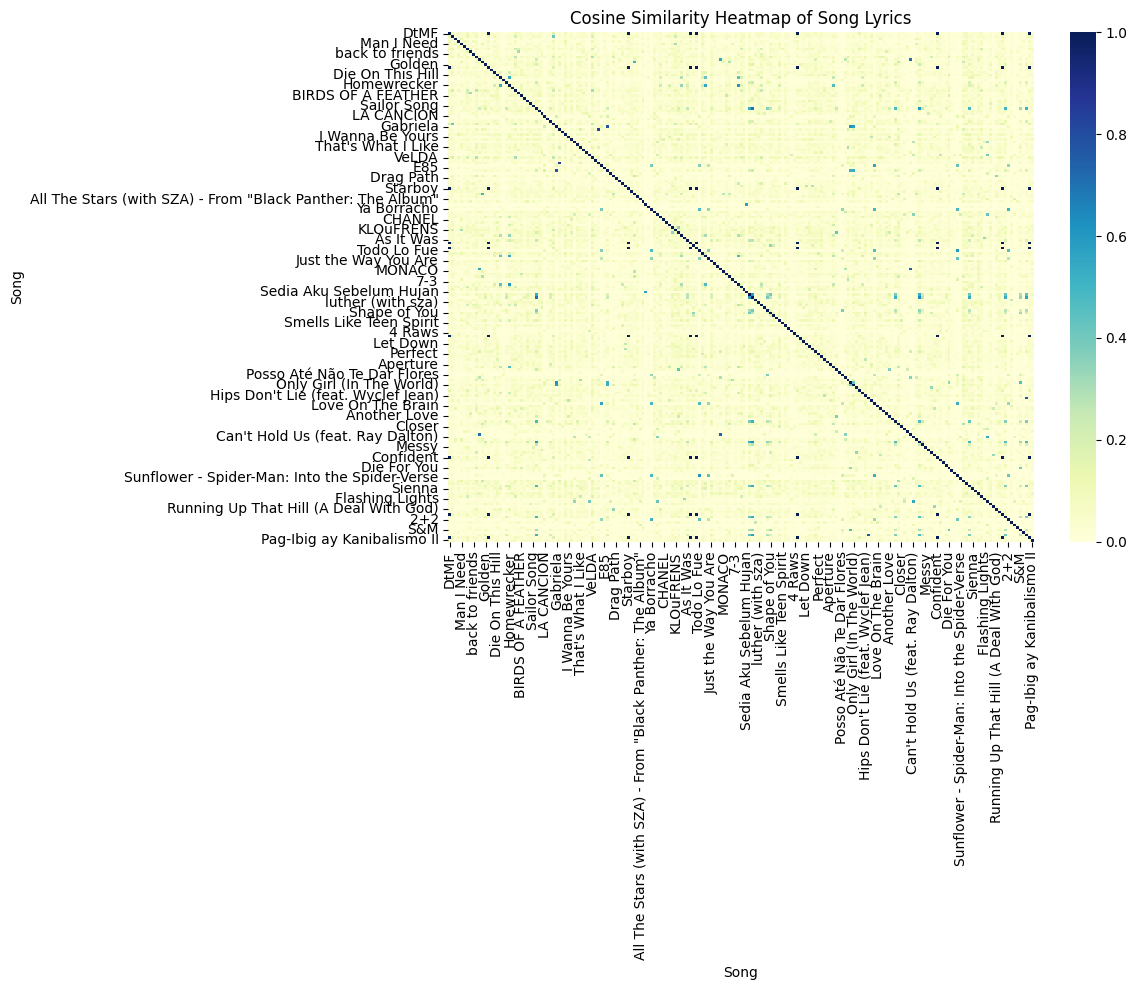

In [4]:
import pandas as pd

sim_df = pd.DataFrame(
    sim_matrix,
    index=df_similarity['track_name'],
    columns=df_similarity['track_name']
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, cmap='YlGnBu')
plt.title('Cosine Similarity Heatmap of Song Lyrics')
plt.xlabel('Song')
plt.ylabel('Song')
plt.tight_layout()
plt.show()

In [ ]:
sns.clustermap(
    sim_df,
    cmap='YlGnBu',
    figsize=(12, 12)
)
plt.suptitle('Clustered Cosine Similarity Heatmap of Songs', y=1.02)
plt.show()

In [ ]:
import plotly.express as px

fig = px.imshow(
    sim_df,
    labels=dict(x="Song", y="Song", color="Cosine Similarity"),
    x=sim_df.columns,
    y=sim_df.index,
    color_continuous_scale='YlGnBu',
    aspect='auto'
)

fig.update_layout(
    title='Interactive Cosine Similarity Heatmap of Song Lyrics',
    width=900,
    height=900
)

fig.show()
fig.write_html("lyrics_similarity_heatmap.html")

In [ ]:
sim_df.index.name

'track_name'

In [6]:
sim_df.columns.name

'track_name'

In [ ]:
import numpy as np
sim_df.index.name = None
sim_df.columns.name = None

mask = np.triu(np.ones(sim_df.shape), k=1).astype(bool)

top_pairs = (
    sim_df.where(mask)
          .stack()
          .reset_index()
)

top_pairs.columns = ['song_1', 'song_2', 'cosine_similarity']

top10_pairs = top_pairs.sort_values(
    by='cosine_similarity', ascending=False
).head(10)

top10_pairs = top10_pairs.reset_index(drop=True)
top10_pairs.insert(0, 'rank', range(1, len(top10_pairs) + 1))

top10_pairs

,rank,song_1,song_2,cosine_similarity
0,1,Feel Good Inc.,Zoo,1.0
1,2,Timeless (feat Playboi Carti),We Don't Talk Anymore (feat. Selena Gomez),1.0
2,3,Apocalypse,Confident,1.0
3,4,Apocalypse,We Don't Talk Anymore (feat. Selena Gomez),1.0
4,5,Apocalypse,Zoo,1.0
5,6,Confident,Zoo,1.0
6,7,DtMF,Starboy,1.0
7,8,Feel Good Inc.,Apocalypse,1.0
8,9,DtMF,Apocalypse,1.0
9,10,Feel Good Inc.,We Don't Talk Anymore (feat. Selena Gomez),1.0


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
coords = pca.fit_transform(X_tfidf.toarray())

plot_df = pd.DataFrame({
    'song_name': df_similarity['track_name'],
    'PC1': coords[:, 0],
    'PC2': coords[:, 1]
})

fig = px.scatter(
    plot_df,
    x='PC1',
    y='PC2',
    hover_name='song_name',
    title='2D Projection of Song Lyrics Based on TF-IDF'
)
fig.show()